#chronic kidney disease

The data was taken over a 2-month period in India with 25 features ( eg, red blood cell count, white blood cell count, etc). The target is the 'classification', which is either 'ckd' or 'notckd' - ckd=chronic kidney disease. There are 400 rows

The data needs cleaning: in that it has NaNs and the numeric features need to be forced to floats. Basically, we were instructed to get rid of ALL ROWS with Nans, with no threshold - meaning, any row that has even one NaN, gets deleted.


#columns
Column Name	Full Feature Name / Description
id	Patient ID
age	Age of the patient (in years)
bp	Blood Pressure (in mm/Hg)
sg	Specific Gravity of urine
al	Albumin level in urine
su	Sugar level in urine
rbc	Red Blood Cells (normal/abnormal)
pc	Pus Cell (normal/abnormal)
pcc	Pus Cell Clumps (present/notpresent)
ba	Bacteria (present/notpresent)
bgr	Blood Glucose Random (in mgs/dl)
bu	Blood Urea (in mgs/dl)
sc	Serum Creatinine (in mgs/dl)
sod	Sodium (in mEq/L)
pot	Potassium (in mEq/L)
hemo	Hemoglobin (in gms)
pcv	Packed Cell Volume
wc	White Blood Cell Count (in cells/cumm)
rc	Red Blood Cell Count (in millions/cumm)
htn	Hypertension (yes/no)
dm	Diabetes Mellitus (yes/no)
cad	Coronary Artery Disease (yes/no)
appet	Appetite (good/poor)
pe	Pedal Edema (yes/no)
ane	Anemia (yes/no)
classification	Target variable: Classification of kidney disease (ckd/notckd)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data=pd.read_csv('/content/drive/MyDrive/project python/Chronic kidney  disease/kidney_disease.csv')#loading the dataset

In [4]:
#to show all the features set the display

pd.set_option('display.max_columns', None)

data #we can able to see all the data features

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51,7200,5.9,no,no,no,good,no,no,notckd


We could their is no proper name for the columns , so lets replace the column names

In [5]:
features = [
    ["id", "Patient ID"],
    ["age", "Age of the patient (in years)"],
    ["bp", "Blood Pressure (in mm/Hg)"],
    ["sg", "Specific Gravity of urine"],
    ["al", "Albumin level in urine"],
    ["su", "Sugar level in urine"],
    ["rbc", "Red Blood Cells (normal / abnormal)"],
    ["pc", "Pus Cell (normal / abnormal)"],
    ["pcc", "Pus Cell Clumps (present / notpresent)"],
    ["ba", "Bacteria (present / notpresent)"],
    ["bgr", "Blood Glucose Random (in mgs/dl)"],
    ["bu", "Blood Urea (in mgs/dl)"],
    ["sc", "Serum Creatinine (in mgs/dl)"],
    ["sod", "Sodium (in mEq/L)"],
    ["pot", "Potassium (in mEq/L)"],
    ["hemo", "Hemoglobin (in gms)"],
    ["pcv", "Packed Cell Volume"],
    ["wc", "White Blood Cell Count (in cells/cumm)"],
    ["rc", "Red Blood Cell Count (in millions/cumm)"],
    ["htn", "Hypertension (yes / no)"],
    ["dm", "Diabetes Mellitus (yes / no)"],
    ["cad", "Coronary Artery Disease (yes / no)"],
    ["appet", "Appetite (good / poor)"],
    ["pe", "Pedal Edema (yes / no)"],
    ["ane", "Anemia (yes / no)"],
    ["classification", "Classification of kidney disease (ckd / notckd)"]
]


data_with_fullnames=data.rename(columns=dict(features))
data_with_fullnames

,Patient ID,Age of the patient (in years),Blood Pressure (in mm/Hg),Specific Gravity of urine,Albumin level in urine,Sugar level in urine,Red Blood Cells (normal / abnormal),Pus Cell (normal / abnormal),Pus Cell Clumps (present / notpresent),Bacteria (present / notpresent),Blood Glucose Random (in mgs/dl),Blood Urea (in mgs/dl),Serum Creatinine (in mgs/dl),Sodium (in mEq/L),Potassium (in mEq/L),Hemoglobin (in gms),Packed Cell Volume,White Blood Cell Count (in cells/cumm),Red Blood Cell Count (in millions/cumm),Hypertension (yes / no),Diabetes Mellitus (yes / no),Coronary Artery Disease (yes / no),Appetite (good / poor),Pedal Edema (yes / no),Anemia (yes / no),Classification of kidney disease (ckd / notckd)
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51,7200,5.9,no,no,no,good,no,no,notckd


In [6]:
#it is hard to mention the full names all the time so lets use the shortcut names only

In [7]:
data.info() #to get the information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

#observations

we could see their are lots of null values in data. so let's see the count of null values below

In [8]:
data.isnull().sum().sort_values(ascending=False)

,0
rbc,152
rc,130
wc,105
pot,88
sod,87
pcv,70
pc,65
hemo,52
su,49
sg,47


In [9]:
#we could see their are lots of null values in rbc,rc,wc,so let's delete these columns


data.drop(["rbc","rc","wc"],axis=1,inplace=True)

In [10]:
data#now we have only 23 columns

,id,age,bp,sg,al,su,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51,no,no,no,good,no,no,notckd


In [11]:
#lets check the null values again

data.isnull().sum().sort_values(ascending=False)

,0
pot,88
sod,87
pcv,70
pc,65
hemo,52
su,49
sg,47
al,46
bgr,44
bu,19


In [12]:
#let's replace the null values with it's median value for numerical column and most frequency for cathegorical column using imputer and column transformer

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



# Identify categorical and numerical columns
cat_col = data.select_dtypes(include='object').columns.tolist()
num_col = data.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:", cat_col)
print("Numerical columns:", num_col)

# Define imputers
cat_impute = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")) #replacing the missing values using mode for cathegorical column
])

num_impute = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")) #replacing the missing values using mdeian for numerical column
])

# Column transformer for preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("cat_impute", cat_impute, cat_col),
    ("num_impute", num_impute, num_col)
], remainder="passthrough")


Categorical columns: ['pc', 'pcc', 'ba', 'pcv', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']
Numerical columns: ['id', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']


In [13]:
cat_col+num_col

['pc',
 'pcc',
 'ba',
 'pcv',
 'htn',
 'dm',
 'cad',
 'appet',
 'pe',
 'ane',
 'classification',
 'id',
 'age',
 'bp',
 'sg',
 'al',
 'su',
 'bgr',
 'bu',
 'sc',
 'sod',
 'pot',
 'hemo']

In [14]:
data1=preprocessor.fit_transform(data)

# data_imputed=preprocessor.transform(data)
# data_imputed,


In [15]:
data_imputed=pd.DataFrame(data1,columns=cat_col+num_col)
data_imputed

,pc,pcc,ba,pcv,htn,dm,cad,appet,pe,ane,classification,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,normal,notpresent,notpresent,44,yes,yes,no,good,no,no,ckd,0.0,48.0,80.0,1.02,1.0,0.0,121.0,36.0,1.2,138.0,4.4,15.4
1,normal,notpresent,notpresent,38,no,no,no,good,no,no,ckd,1.0,7.0,50.0,1.02,4.0,0.0,121.0,18.0,0.8,138.0,4.4,11.3
2,normal,notpresent,notpresent,31,no,yes,no,poor,no,yes,ckd,2.0,62.0,80.0,1.01,2.0,3.0,423.0,53.0,1.8,138.0,4.4,9.6
3,abnormal,present,notpresent,32,yes,no,no,poor,yes,yes,ckd,3.0,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2
4,normal,notpresent,notpresent,35,no,no,no,good,no,no,ckd,4.0,51.0,80.0,1.01,2.0,0.0,106.0,26.0,1.4,138.0,4.4,11.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,normal,notpresent,notpresent,47,no,no,no,good,no,no,notckd,395.0,55.0,80.0,1.02,0.0,0.0,140.0,49.0,0.5,150.0,4.9,15.7
396,normal,notpresent,notpresent,54,no,no,no,good,no,no,notckd,396.0,42.0,70.0,1.025,0.0,0.0,75.0,31.0,1.2,141.0,3.5,16.5
397,normal,notpresent,notpresent,49,no,no,no,good,no,no,notckd,397.0,12.0,80.0,1.02,0.0,0.0,100.0,26.0,0.6,137.0,4.4,15.8
398,normal,notpresent,notpresent,51,no,no,no,good,no,no,notckd,398.0,17.0,60.0,1.025,0.0,0.0,114.0,50.0,1.0,135.0,4.9,14.2


In [16]:
data_imputed.isnull().sum().sort_values(ascending=False)

,0
pc,0
pcc,0
ba,0
pcv,0
htn,0
dm,0
cad,0
appet,0
pe,0
ane,0


#Observations

now we could see thier is no any of the missing values

#Exploratory Data Analysis (EDA)


Let's the value counts directly

In [18]:
for i in data_imputed[cat_col].columns:
  print(i,data_imputed[i].unique())

pc ['normal' 'abnormal']
pcc ['notpresent' 'present']
ba ['notpresent' 'present']
pcv ['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' '41' '16' '24' '37'
 '30' '34' '40' '45' '27' '48' '\t?' '52' '14' '22' '18' '42' '17' '46'
 '23' '19' '25' '26' '15' '21' '43' '20' '\t43' '47' '9' '49' '50' '53'
 '51' '54']
htn ['yes' 'no']
dm ['yes' 'no' ' yes' '\tno' '\tyes']
cad ['no' 'yes' '\tno']
appet ['good' 'poor']
pe ['no' 'yes']
ane ['no' 'yes']
classification ['ckd' 'ckd\t' 'notckd']


#As we checked we have an special symblos in values in pcv,dm,cad,and classification featres like \types ,\tno etc
, so we can replace those values

In [19]:
#replacing the dm data into the correct data by removing the special symbols in it

data_imputed["dm"]=data_imputed["dm"].replace({" yes":"yes","\tno":"no"," yes":"yes"," no":"no",'\tyes':"yes"})
data_imputed["dm"].unique(),data_imputed["dm"].value_counts()#after mapping the data

(array(['yes', 'no'], dtype=object),
 dm
 no     263
 yes    137
 Name: count, dtype: int64)

In [20]:
data_imputed["cad"]=data_imputed["cad"].replace({" yes":"yes","\tno":"no"," yes":"yes"," no":"no"})
data_imputed["cad"].unique()#after mapping the data
data_imputed["cad"].value_counts()

,count
cad,
no,366
yes,34


In [21]:
data_imputed.classification=data.classification.apply(lambda x:x.replace("ckd\t","ckd"))
data_imputed.classification.unique() #now it has been updated with the proper data

array(['ckd', 'notckd'], dtype=object)

In [22]:
data_imputed["pcv"]=data_imputed["pcv"].str.replace('\t',"").replace('?',"0").replace("",0)

In [23]:
data_imputed.pcv.unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', '41',
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '0', '52',
       '14', '22', '18', '42', '17', '46', '23', '19', '25', '26', '15',
       '21', '43', '20', '47', '9', '49', '50', '53', '51', '54'],
      dtype=object)

In [24]:
for i in data_imputed[cat_col].columns:
  print(i,data_imputed[i].unique())

pc ['normal' 'abnormal']
pcc ['notpresent' 'present']
ba ['notpresent' 'present']
pcv ['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' '41' '16' '24' '37'
 '30' '34' '40' '45' '27' '48' '0' '52' '14' '22' '18' '42' '17' '46' '23'
 '19' '25' '26' '15' '21' '43' '20' '47' '9' '49' '50' '53' '51' '54']
htn ['yes' 'no']
dm ['yes' 'no']
cad ['no' 'yes']
appet ['good' 'poor']
pe ['no' 'yes']
ane ['no' 'yes']
classification ['ckd' 'notckd']


In [25]:
#converting pcv into numerical data

data_imputed["pcv"]=data_imputed["pcv"].astype("int")


In [26]:
data_imputed.pcv.dtype

dtype('int64')

In [27]:
cat_cols = data_imputed.select_dtypes(include='object').columns.tolist()
cat_col=cat_cols[0:10]
data_imputed[cat_col]
# num_col=data_imputed.select_dtypes(exclude='object').columns.tolist()
num_col=cat_cols[10:]
data_imputed[num_col]

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,0.0,48.0,80.0,1.02,1.0,0.0,121.0,36.0,1.2,138.0,4.4,15.4
1,1.0,7.0,50.0,1.02,4.0,0.0,121.0,18.0,0.8,138.0,4.4,11.3
2,2.0,62.0,80.0,1.01,2.0,3.0,423.0,53.0,1.8,138.0,4.4,9.6
3,3.0,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2
4,4.0,51.0,80.0,1.01,2.0,0.0,106.0,26.0,1.4,138.0,4.4,11.6
...,...,...,...,...,...,...,...,...,...,...,...,...
395,395.0,55.0,80.0,1.02,0.0,0.0,140.0,49.0,0.5,150.0,4.9,15.7
396,396.0,42.0,70.0,1.025,0.0,0.0,75.0,31.0,1.2,141.0,3.5,16.5
397,397.0,12.0,80.0,1.02,0.0,0.0,100.0,26.0,0.6,137.0,4.4,15.8
398,398.0,17.0,60.0,1.025,0.0,0.0,114.0,50.0,1.0,135.0,4.9,14.2


In [28]:
data_imputed[num_col]=data_imputed[num_col].astype("float")

In [29]:
data_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pc              400 non-null    object 
 1   pcc             400 non-null    object 
 2   ba              400 non-null    object 
 3   pcv             400 non-null    int64  
 4   htn             400 non-null    object 
 5   dm              400 non-null    object 
 6   cad             400 non-null    object 
 7   appet           400 non-null    object 
 8   pe              400 non-null    object 
 9   ane             400 non-null    object 
 10  classification  400 non-null    object 
 11  id              400 non-null    float64
 12  age             400 non-null    float64
 13  bp              400 non-null    float64
 14  sg              400 non-null    float64
 15  al              400 non-null    float64
 16  su              400 non-null    float64
 17  bgr             400 non-null    flo

In [30]:
data_imputed["hemo"].unique()

array([15.4 , 11.3 ,  9.6 , 11.2 , 11.6 , 12.2 , 12.4 , 10.8 ,  9.5 ,
        9.4 ,  9.7 ,  9.8 ,  5.6 ,  7.6 , 12.6 , 12.1 , 12.7 , 10.3 ,
        7.7 , 10.9 , 12.65, 11.1 ,  9.9 , 12.5 , 12.9 , 10.1 , 12.  ,
       13.  ,  7.9 ,  9.3 , 15.  , 10.  ,  8.6 , 13.6 , 10.2 , 10.5 ,
        6.6 , 11.  ,  7.5 , 15.6 , 15.2 ,  4.8 ,  9.1 ,  8.1 , 11.9 ,
       13.5 ,  8.3 ,  7.1 , 16.1 , 10.4 ,  9.2 ,  6.2 , 13.9 , 14.1 ,
        6.  , 11.8 , 11.7 , 11.4 , 14.  ,  8.2 , 13.2 ,  6.1 ,  8.  ,
       12.3 ,  8.4 , 14.3 ,  9.  ,  8.7 , 10.6 , 13.1 , 10.7 ,  5.5 ,
        5.8 ,  6.8 ,  8.8 ,  8.5 , 13.8 , 11.5 ,  7.3 , 13.7 , 12.8 ,
       13.4 ,  6.3 ,  3.1 , 17.  , 15.9 , 14.5 , 15.5 , 16.2 , 14.4 ,
       14.2 , 16.3 , 14.8 , 16.5 , 15.7 , 13.3 , 14.6 , 16.4 , 16.9 ,
       16.  , 14.7 , 16.6 , 14.9 , 16.7 , 16.8 , 15.8 , 15.1 , 17.1 ,
       17.2 , 15.3 , 17.3 , 17.4 , 17.7 , 17.8 , 17.5 , 17.6 ])

#now we have replaced all the missing values and converted few columns to int and float

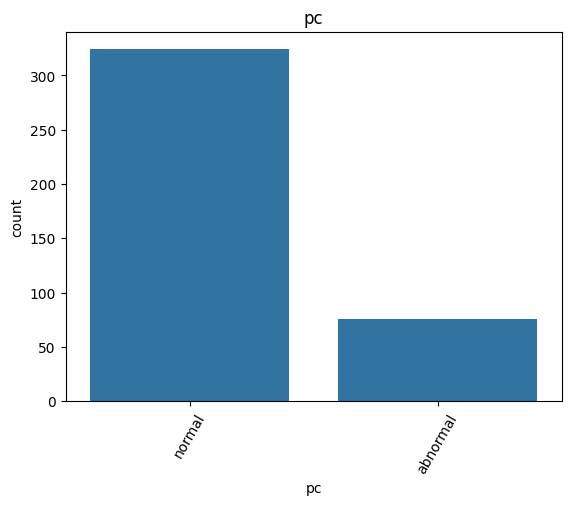

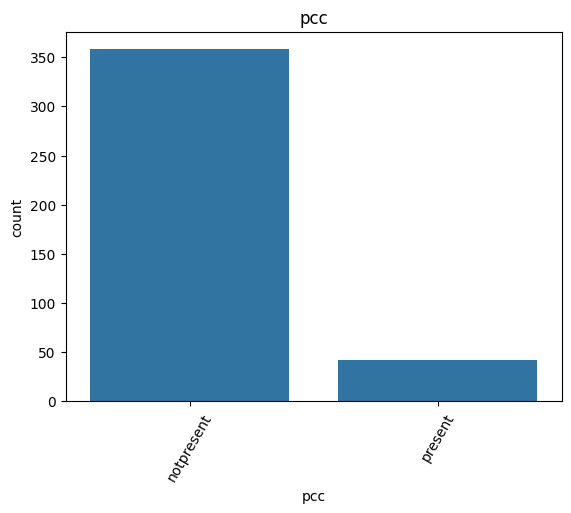

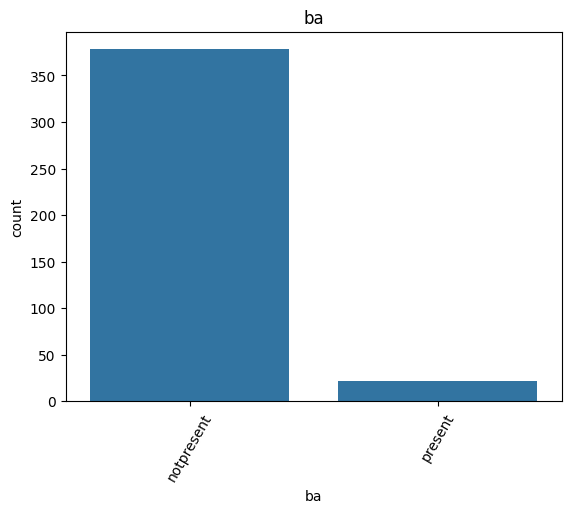

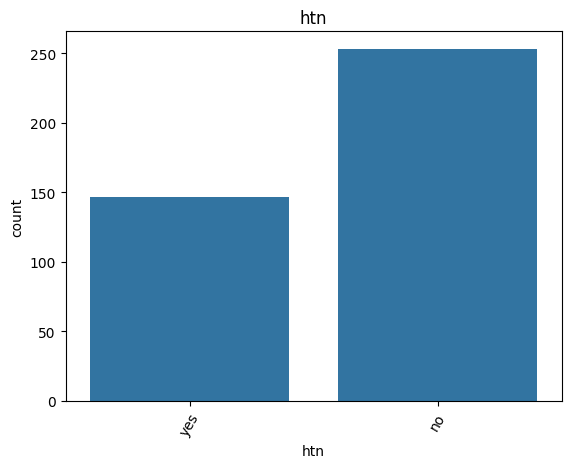

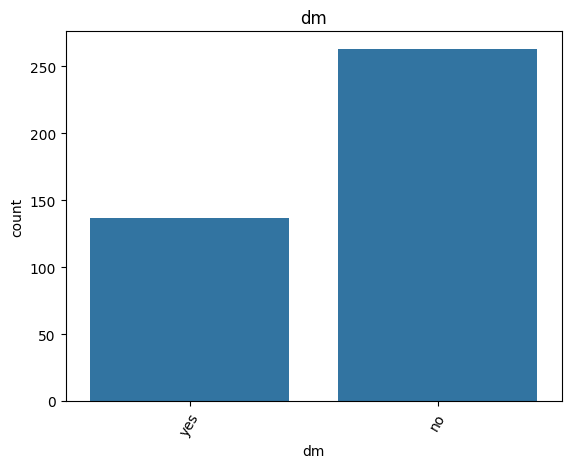

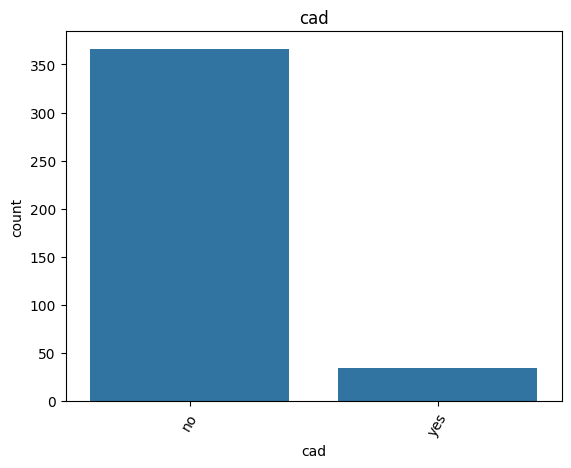

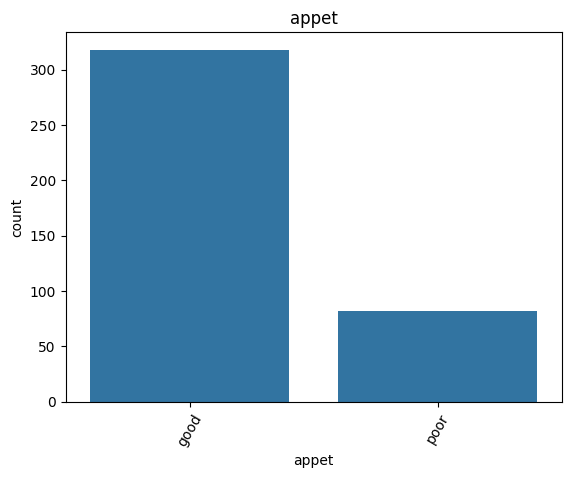

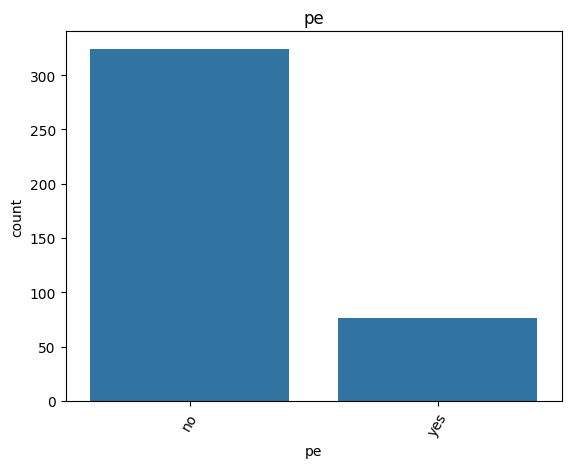

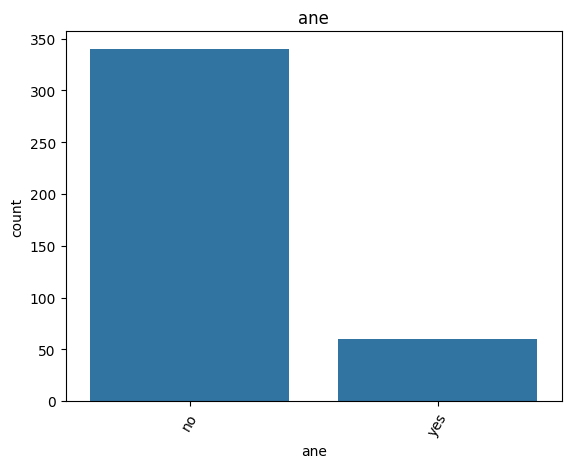

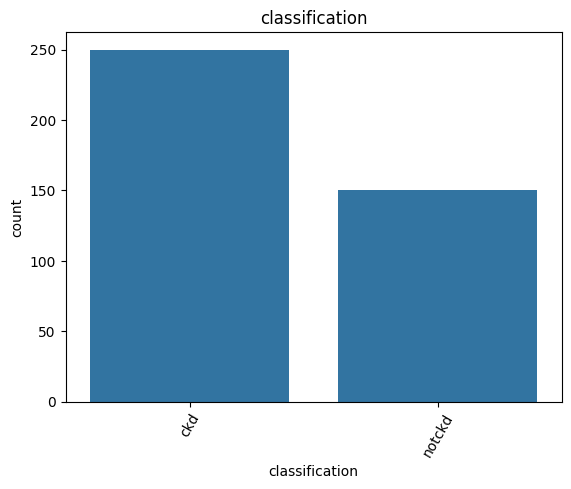

In [31]:
#let's see the values count in cathegorical columns by visualizing
for i in data_imputed[cat_col].columns:
  plt.title(i)
  sns.countplot(data=data_imputed,x=i)
  plt.xticks(rotation=60)
  plt.show()

#let's see if we have any outliers using boxplot for numeric data

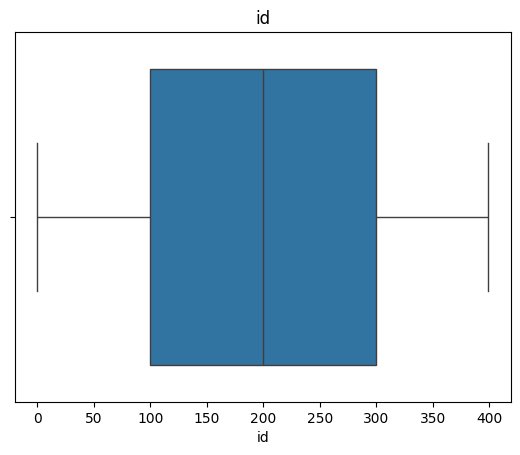

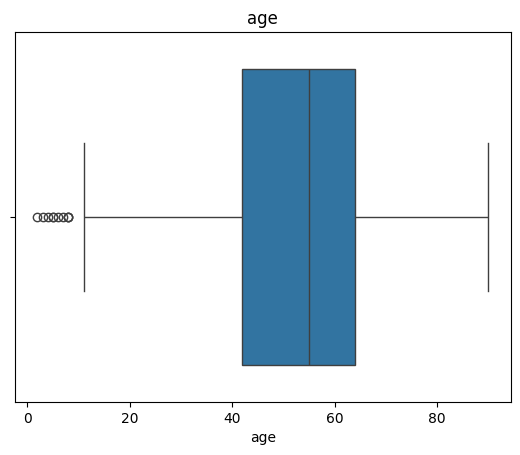

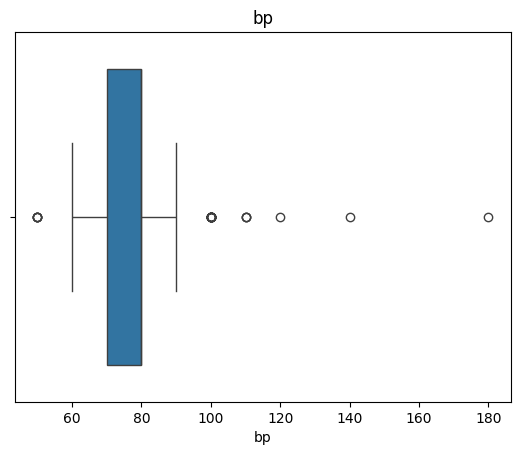

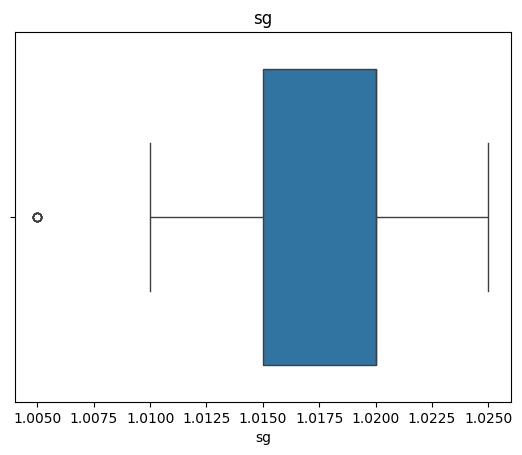

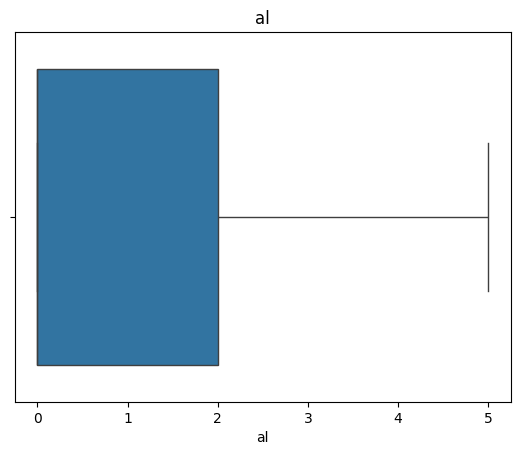

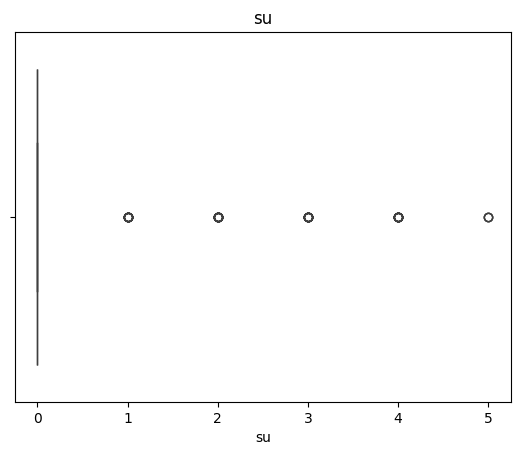

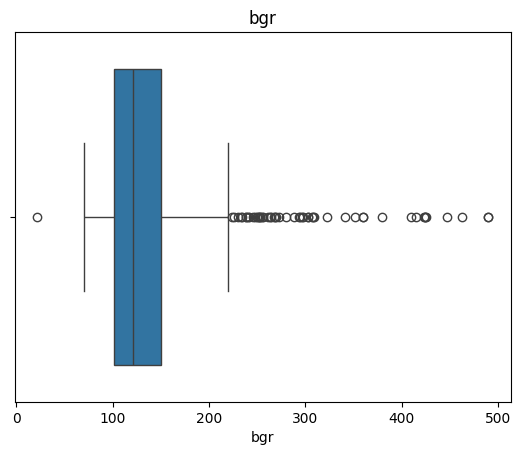

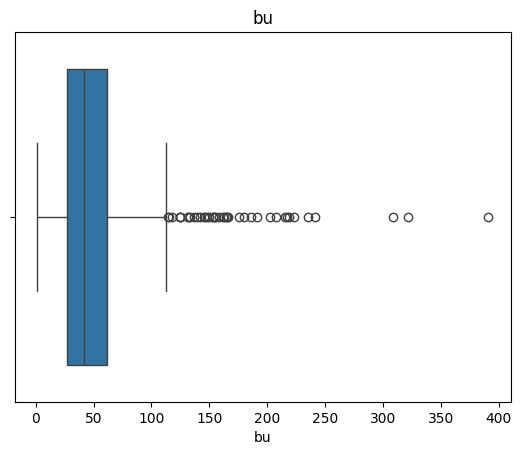

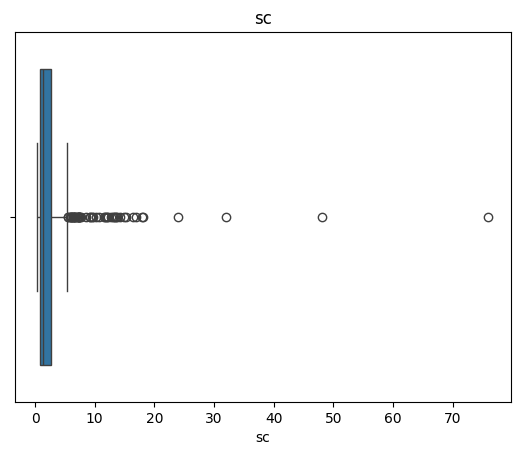

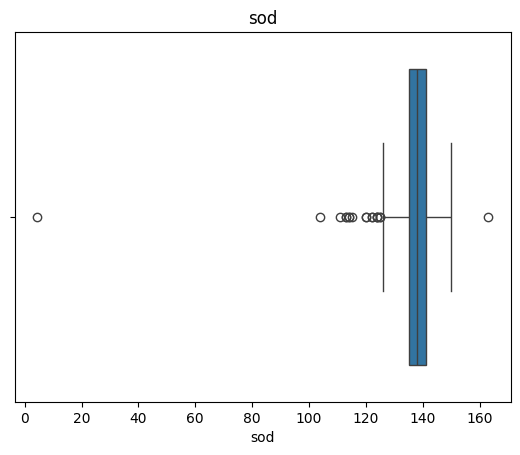

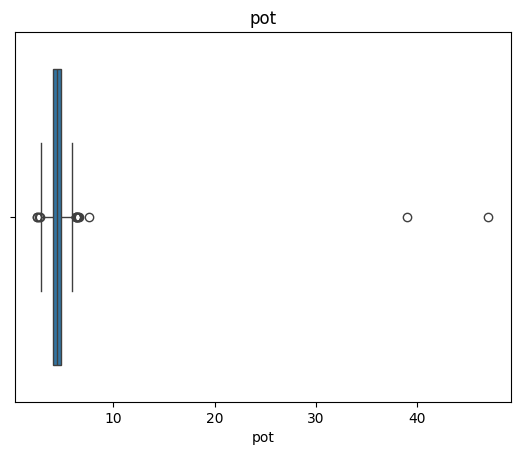

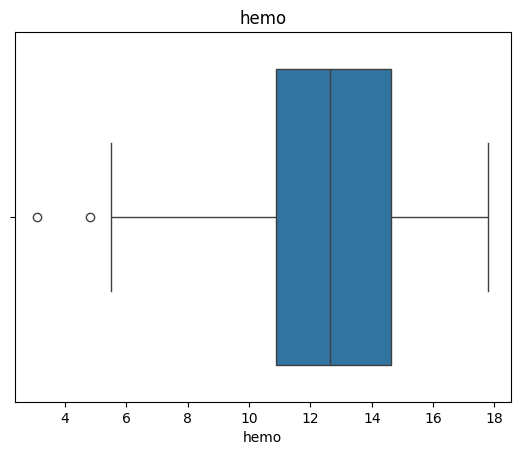

In [32]:
for i in num_col:
  plt.title(i)
  sns.boxplot(data=data_imputed,x=i)
  plt.show()

In [33]:
#we could see we have few outliers in few  columns , so we can replace the outliers with values of lowerfence and upperfence

for i in num_col:
  q1=data_imputed[i].quantile(0.25)
  q3=data_imputed[i].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr

  data_imputed[i]=np.where(data_imputed[i]<lower_bound,lower_bound,data_imputed[i])
  data_imputed[i]=np.where(data_imputed[i]>upper_bound,upper_bound,data_imputed[i])



#let's see if we have any outliers using boxplot for numeric data after removing the outliers

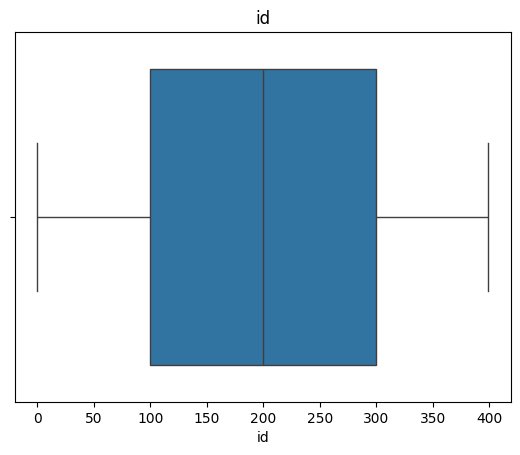

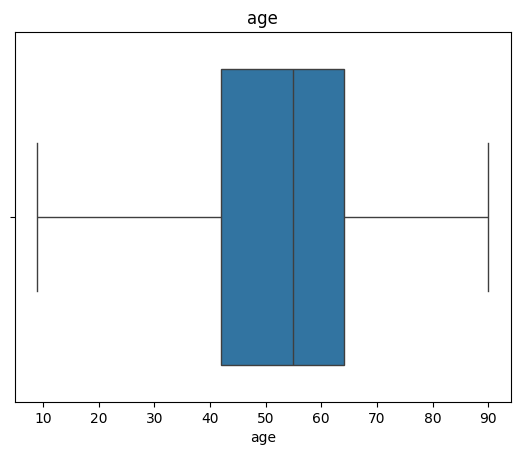

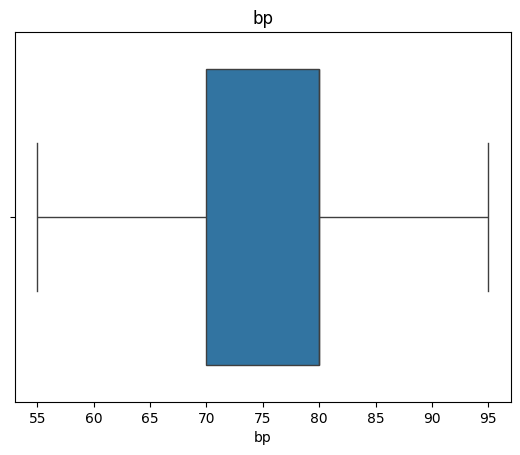

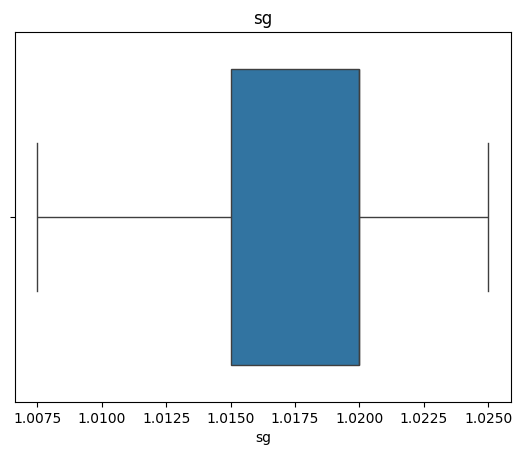

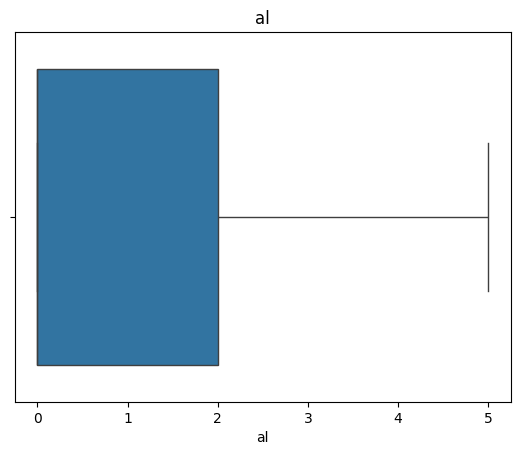

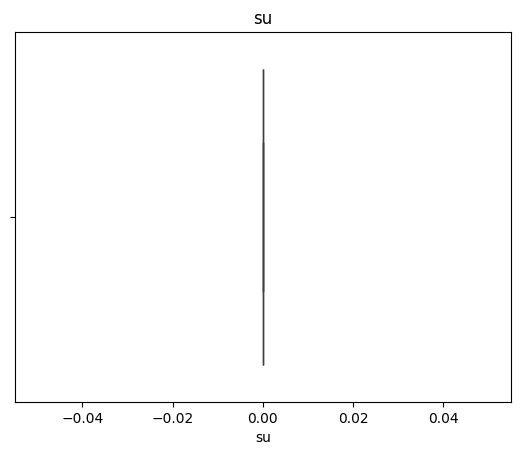

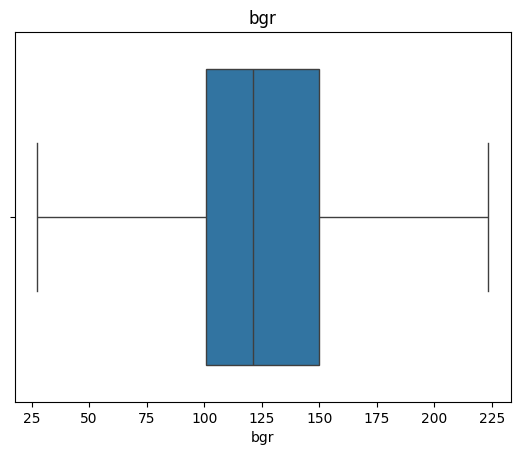

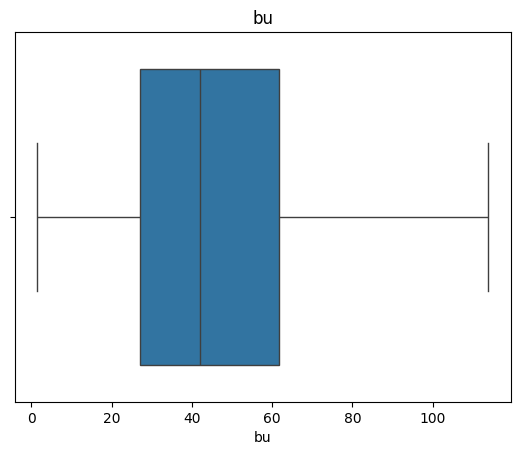

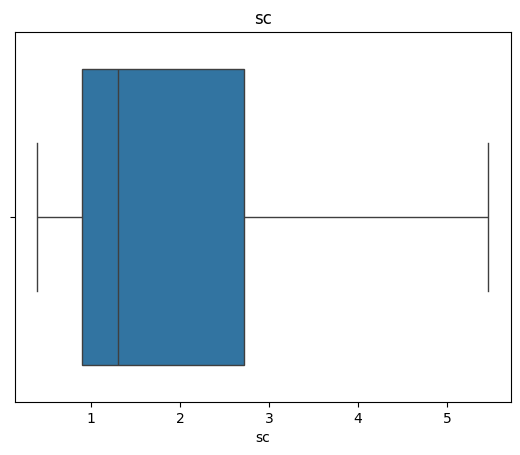

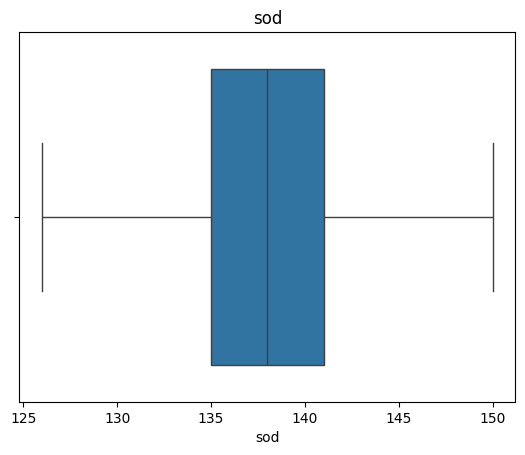

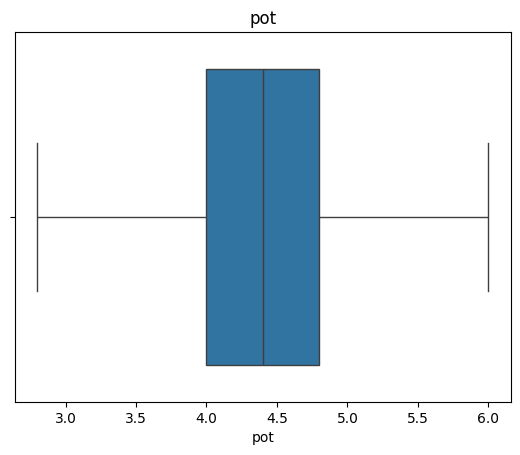

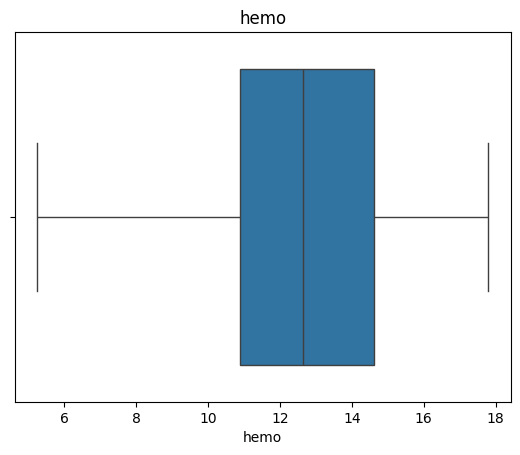

In [34]:
for i in num_col:
  plt.title(i)
  sns.boxplot(data=data_imputed,x=i)
  plt.show()

#now we could see thier is no any outliers

In [35]:
data_imputed["dm"].value_counts()

,count
dm,
no,263
yes,137


In [36]:
for i in cat_col:
  print(data_imputed[i].unique())#now we could see all the cathegorical values has been replaced with the correct values by removing the space and special symbols

['normal' 'abnormal']
['notpresent' 'present']
['notpresent' 'present']
['yes' 'no']
['yes' 'no']
['no' 'yes']
['good' 'poor']
['no' 'yes']
['no' 'yes']
['ckd' 'notckd']


#now we could see their is no any outliers and all the cathegorical and numeric columns are fine

#let's visualize the pairplot

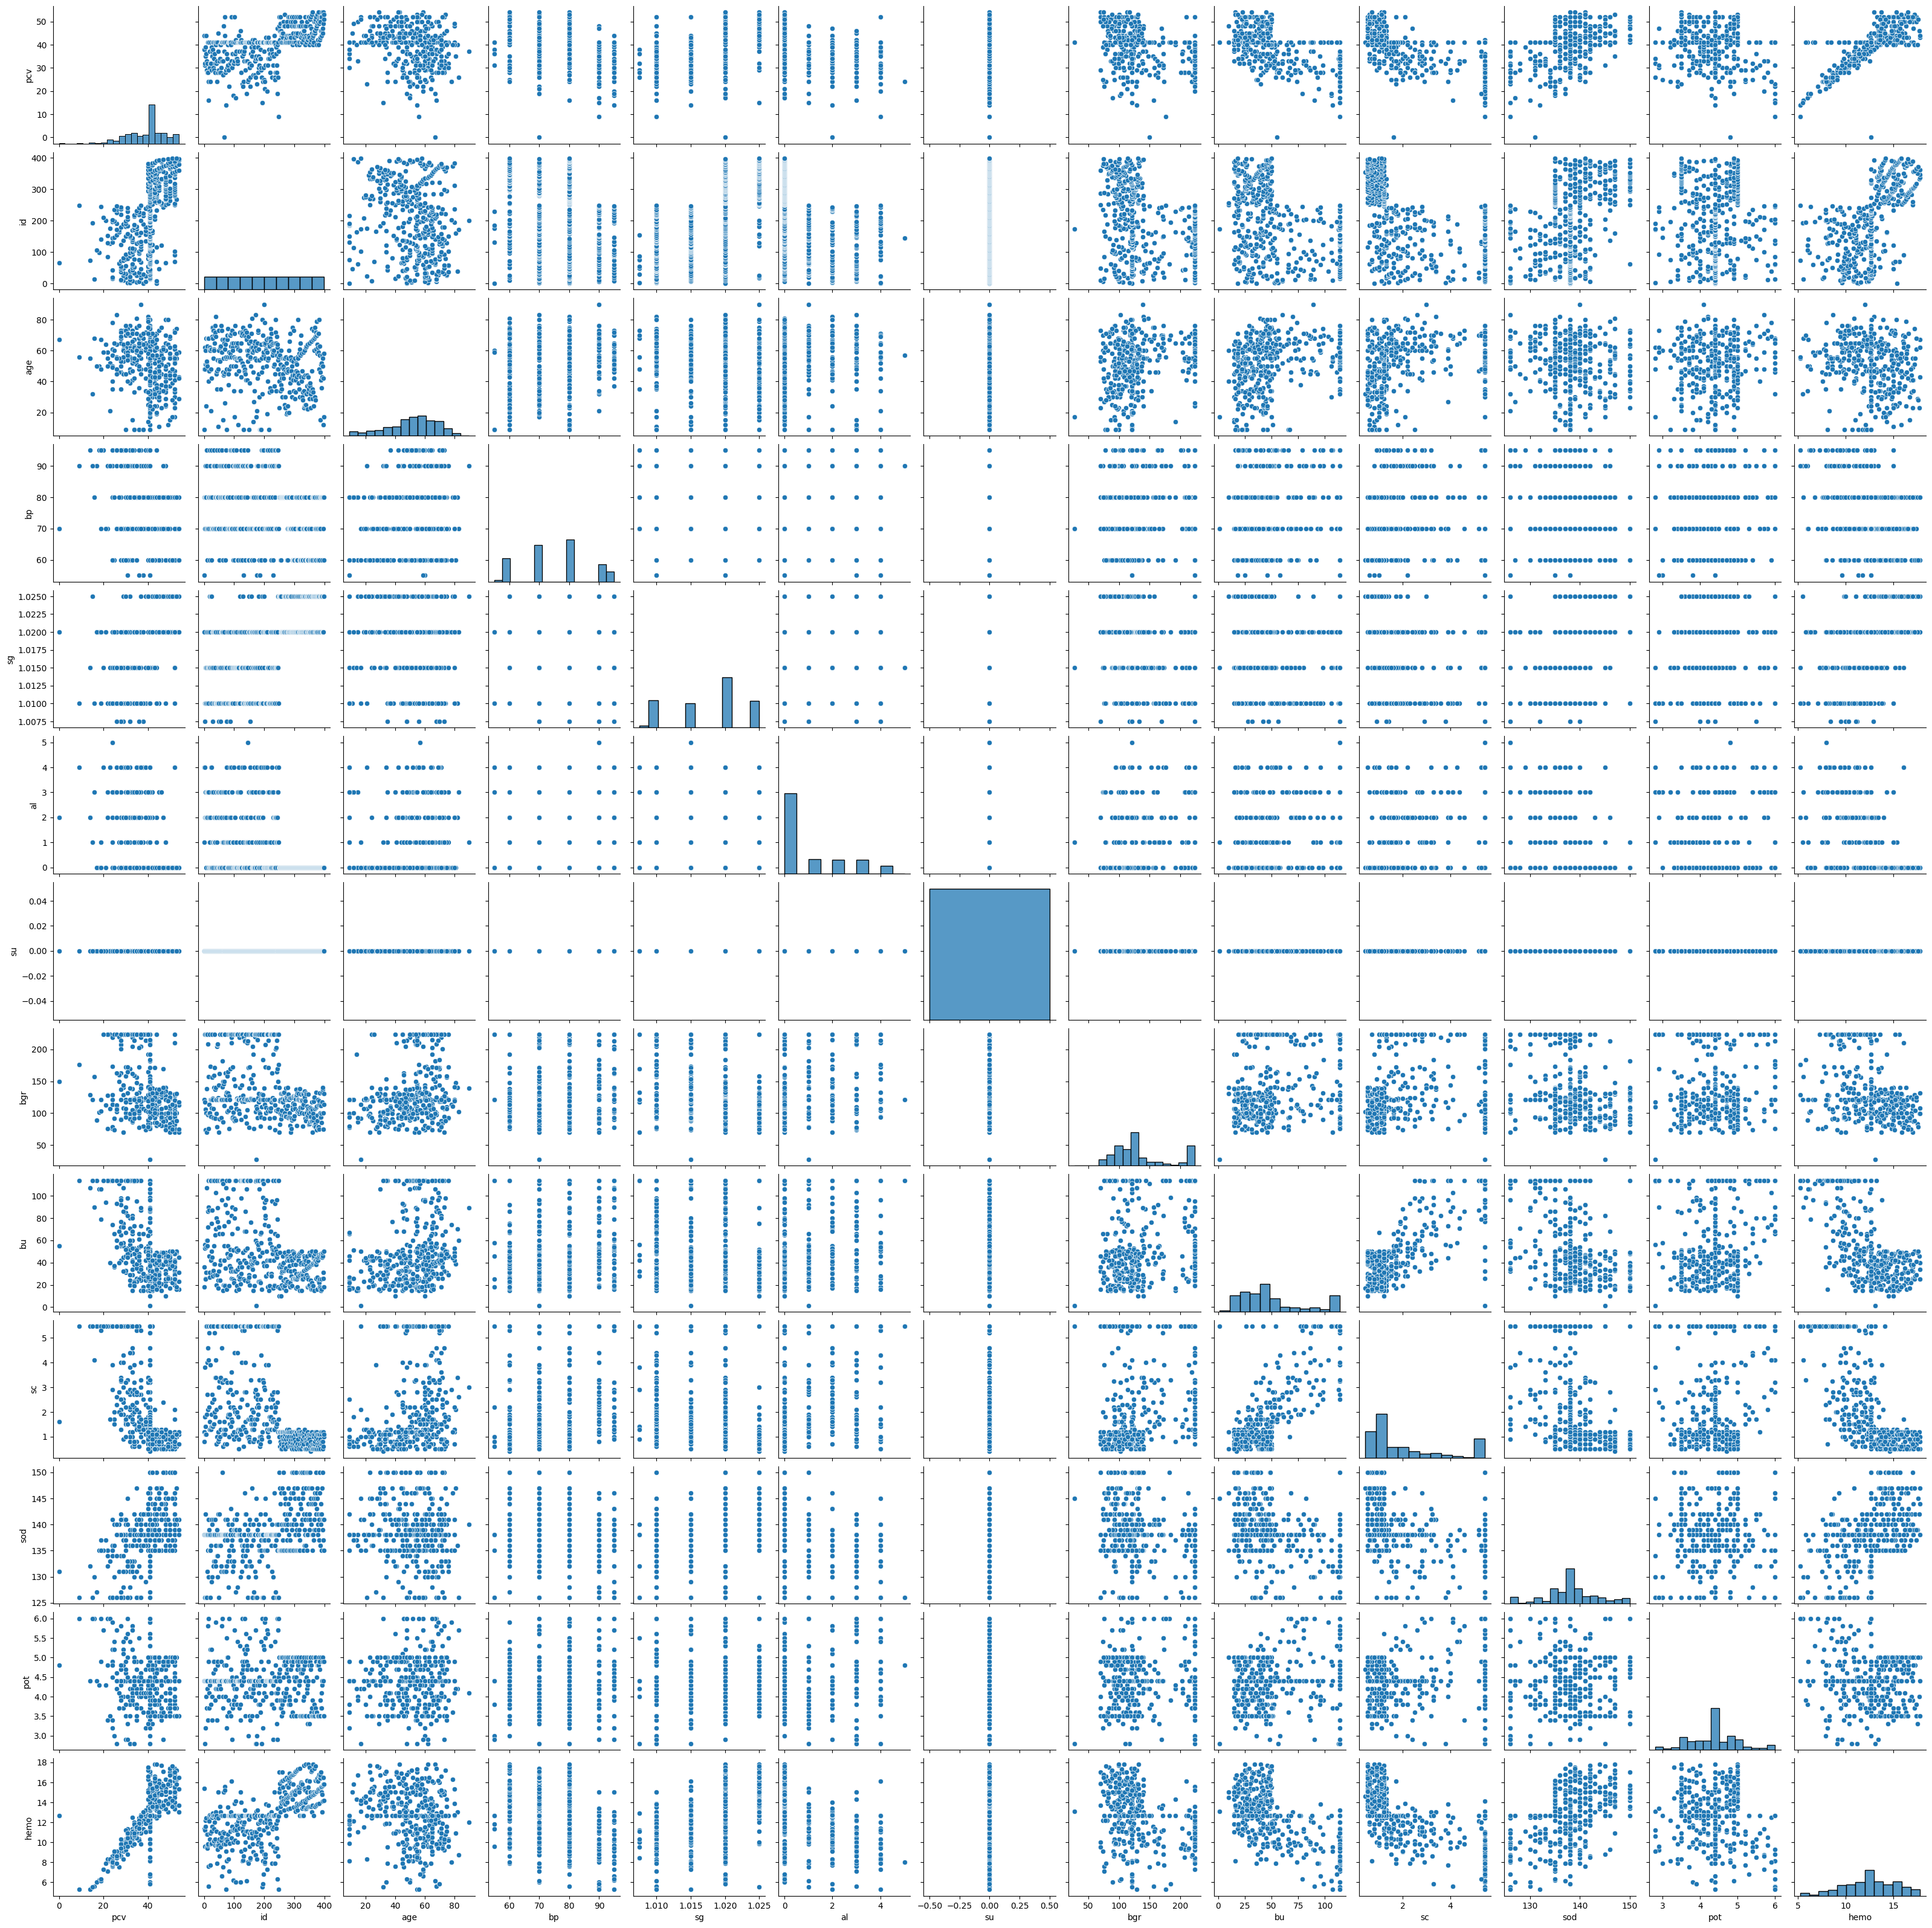

In [37]:
sns.pairplot(data_imputed)

#if we have lots of columns then that's better not to go for pairplot as it will be hard to see the visualizations and time consuming

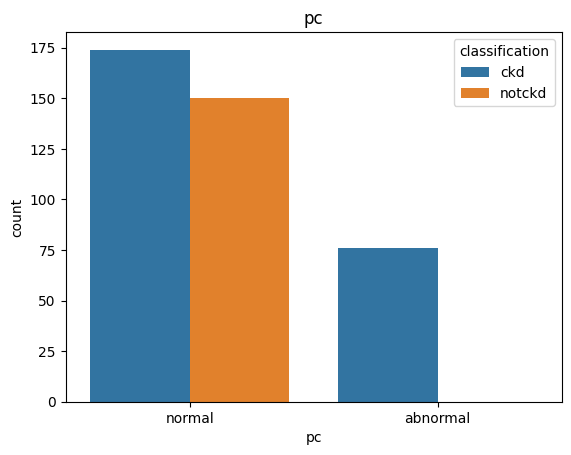

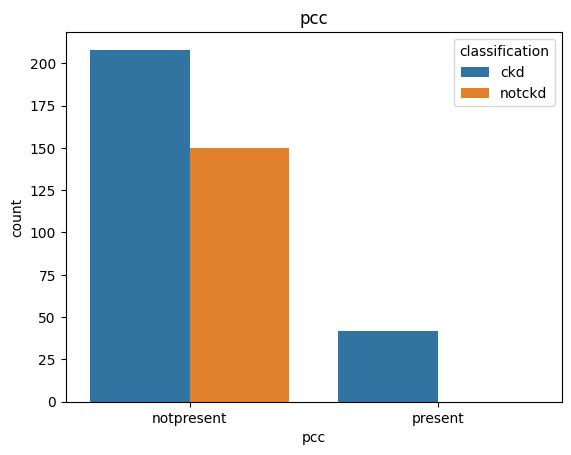

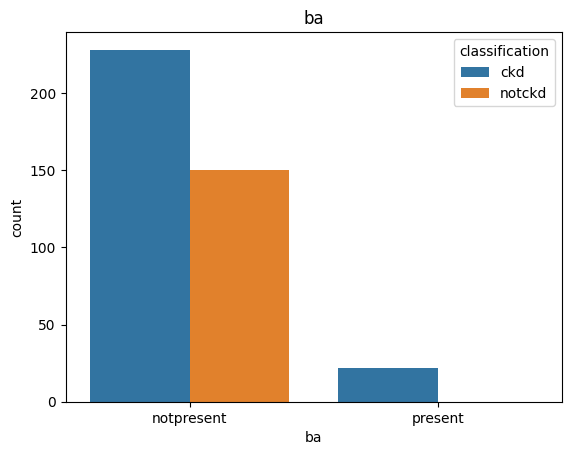

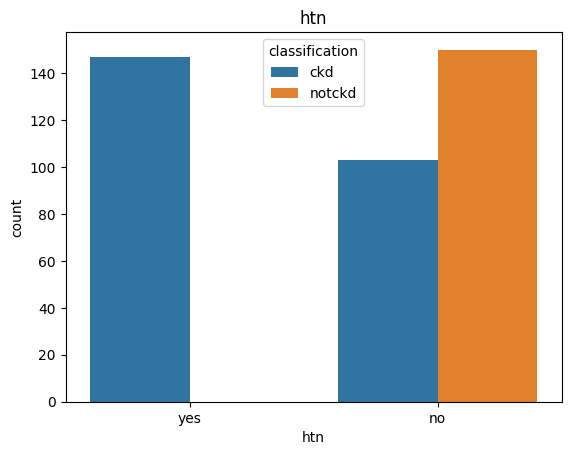

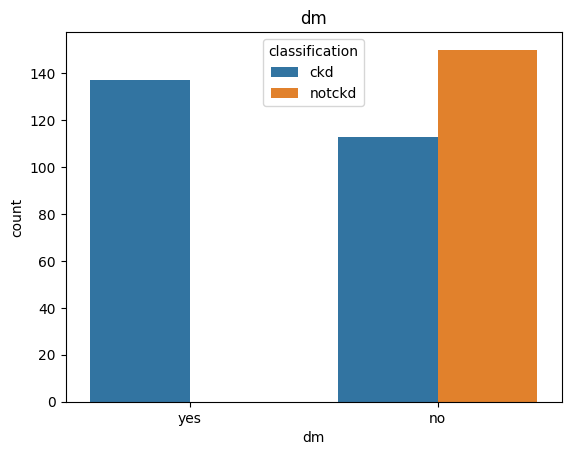

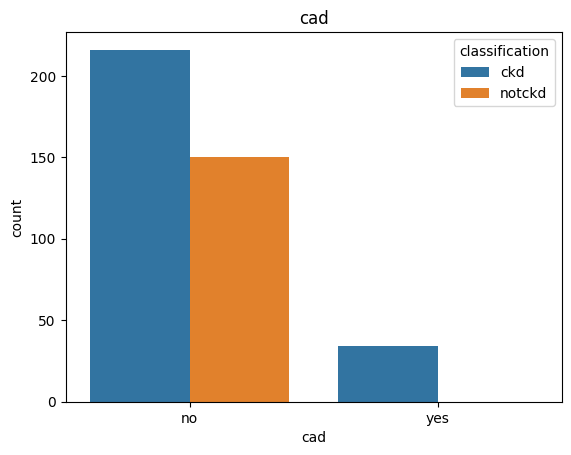

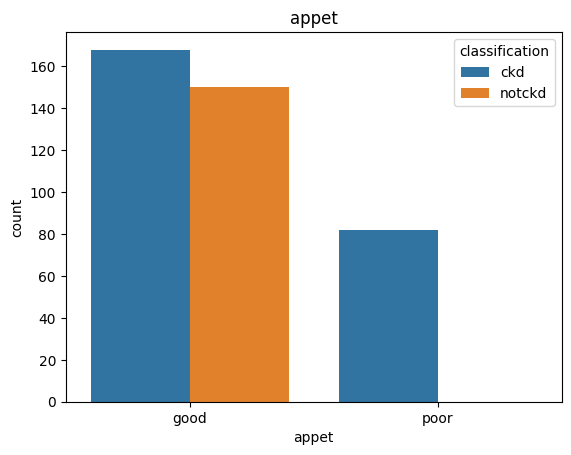

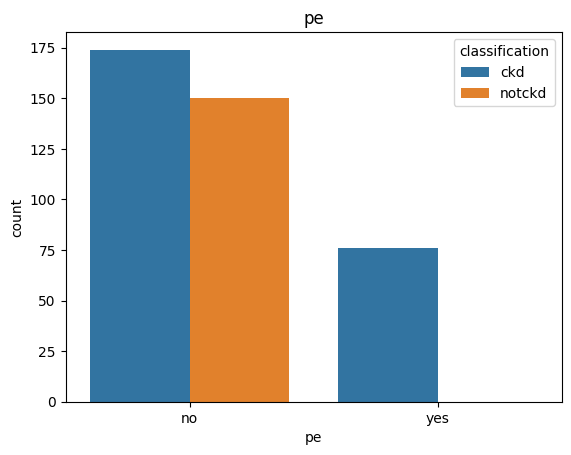

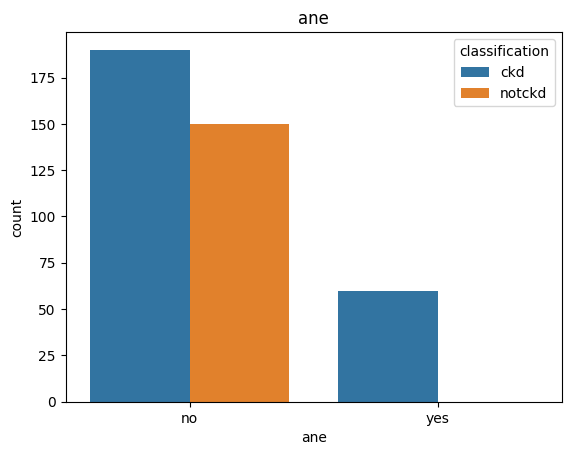

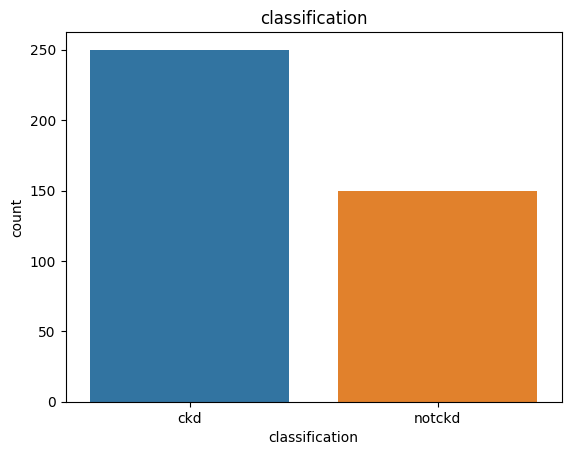

In [38]:
#visualizing count plot
for i in data_imputed[cat_col]:
  plt.title(i)
  sns.countplot(data=data_imputed,x=i,hue="classification")
  plt.show()


<Axes: >

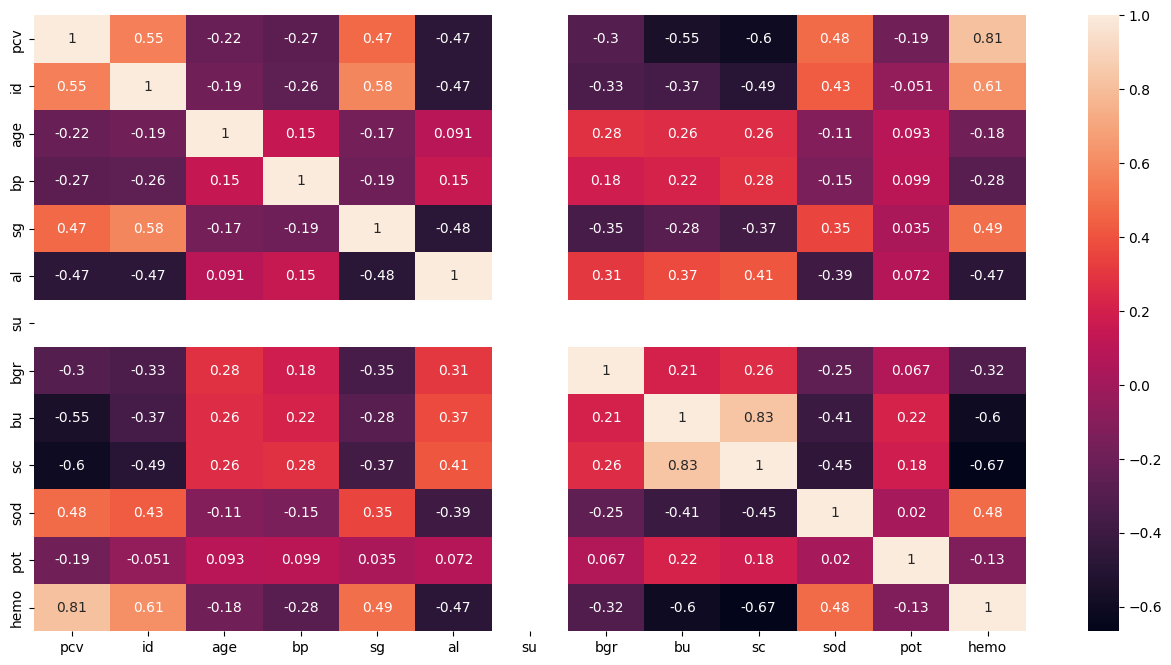

In [39]:
plt.figure(figsize=(16,8))
sns.heatmap(data_imputed.corr(numeric_only=True),annot=True) #correlation between numerical data

#insights
we could see their is high correlation between bu and sc

In [40]:
data_imputed[cat_col]

,pc,pcc,ba,htn,dm,cad,appet,pe,ane,classification
0,normal,notpresent,notpresent,yes,yes,no,good,no,no,ckd
1,normal,notpresent,notpresent,no,no,no,good,no,no,ckd
2,normal,notpresent,notpresent,no,yes,no,poor,no,yes,ckd
3,abnormal,present,notpresent,yes,no,no,poor,yes,yes,ckd
4,normal,notpresent,notpresent,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...
395,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
396,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
397,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
398,normal,notpresent,notpresent,no,no,no,good,no,no,notckd


#will convert the cathegorical values into numeric values as machine won't understand the cathegorical data

In [41]:
from sklearn.preprocessing import LabelEncoder #encoding

encode=LabelEncoder()
for i in cat_col:
  encode.fit(data_imputed[i])
  data_imputed[i]=encode.transform(data_imputed[i])
data_imputed[cat_col]

,pc,pcc,ba,htn,dm,cad,appet,pe,ane,classification
0,1,0,0,1,1,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0
2,1,0,0,0,1,0,1,0,1,0
3,0,1,0,1,0,0,1,1,1,0
4,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
395,1,0,0,0,0,0,0,0,0,1
396,1,0,0,0,0,0,0,0,0,1
397,1,0,0,0,0,0,0,0,0,1
398,1,0,0,0,0,0,0,0,0,1


In [42]:
data_imputed.dtypes

,0
pc,int64
pcc,int64
ba,int64
pcv,int64
htn,int64
dm,int64
cad,int64
appet,int64
pe,int64
ane,int64


#now all the data is in numeric

In [43]:
#splitting the data

x=data_imputed.drop("classification",axis=1)
y=data_imputed.classification

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


x_train.shape,x_test.shape,y_train.shape,y_test.shape

((320, 22), (80, 22), (320,), (80,))

In [44]:
#scaling

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

x_train

,pc,pcc,ba,pcv,htn,dm,cad,appet,pe,ane,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
3,0,1,0,32,1,0,0,1,1,1,3.0,48.0,70.0,1.0075,4.0,0.0,117.0,56.000,3.8000,126.0,2.8,11.2
18,1,0,0,37,1,1,1,0,0,0,18.0,60.0,95.0,1.0250,0.0,0.0,223.5,27.000,1.3000,135.0,4.3,12.7
202,1,0,0,24,0,1,0,0,0,1,202.0,78.0,60.0,1.0200,0.0,0.0,114.0,74.000,2.9000,135.0,5.9,8.0
250,1,0,0,48,0,0,0,0,0,0,250.0,40.0,80.0,1.0250,0.0,0.0,140.0,10.000,1.2000,135.0,5.0,15.0
274,1,0,0,44,0,0,0,0,0,0,274.0,19.0,80.0,1.0200,0.0,0.0,107.0,23.000,0.7000,141.0,4.2,14.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,1,0,0,28,1,1,0,0,0,0,71.0,46.0,60.0,1.0100,1.0,0.0,163.0,92.000,3.3000,141.0,4.0,9.8
106,1,0,0,17,1,1,0,0,1,1,106.0,50.0,90.0,1.0200,0.0,0.0,89.0,113.875,5.4625,127.0,4.4,6.0
270,1,0,0,41,0,0,0,0,0,0,270.0,23.0,80.0,1.0250,0.0,0.0,111.0,34.000,1.1000,145.0,4.0,14.3
348,1,0,0,44,0,0,0,0,0,0,348.0,38.0,80.0,1.0200,0.0,0.0,99.0,19.000,0.5000,147.0,3.5,13.6


#modelling

As we are predicting the classification data we will use n number of classification data to predict the data and will see which classification algorithm is working fine

#let's predict with logistic regression

Here we will use binary logoistic regression as we have only 2 outcomes

In [59]:
#lets have an empty dataframe to store all the training and testing accuracies of models

model_accuraries=pd.DataFrame(columns=["Models","Training Accuracy","Testing Accuracy"])
model_accuraries

,Models,Training Accuracy,Testing Accuracy


In [60]:
#importing the requires libraries and classes for logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

lr=LogisticRegression() #object craetion of logistic model

lr.fit(x_train,y_train) #fitting the model

lr_train_acc=lr.predict(x_train) #prediction on training data

lr_test_acc=lr.predict(x_test)#prediction on testing data

train_accuracy=accuracy_score(y_train,lr_train_acc) #accuracy on training data
test_accuracy=accuracy_score(y_test,lr_test_acc) #accuracy on testing data

print("Confusion matrix:")
print(confusion_matrix(y_test,lr_test_acc))
print("Classification report:")
print(classification_report(y_test,lr_test_acc))


accuracy=pd.DataFrame({"Models":["Logistic Regression"],"Training Accuracy":[train_accuracy],"Testing Accuracy":[test_accuracy]})
model_accuraries=pd.concat([model_accuraries,accuracy],ignore_index=True)
model_accuraries


Confusion matrix:
[[52  0]
 [ 0 28]]
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



,Models,Training Accuracy,Testing Accuracy
0,Logistic Regression,1.0,1.0


#wow

we have 100% accuracy in both training and testing data

#now will we try the same logistic regression with some error using hyperparameter , may be in previous predict it could have memorized the data

In [63]:
from sklearn.model_selection import GridSearchCV

params={"penalty":["l2","l1","elasticnet"]}

grid_lr=GridSearchCV(estimator=LogisticRegression(),param_grid=params,cv=5)
grid_lr.fit(x_train,y_train)
best_estimator=grid_lr.best_estimator_

y_train_pred=best_estimator.predict(x_train)
y_test_pred=best_estimator.predict(x_test)


train_accuracy=accuracy_score(y_train,y_train_pred) #accuracy on training data
test_accuracy=accuracy_score(y_test,y_test_pred) #accuracy on testing data

print("Confusion matrix:")
print(confusion_matrix(y_test,y_test_pred))
print("Classification report:")
print(classification_report(y_test,y_test_pred))
#let's which parameter is good

print("best estimator",grid_lr.best_params_)

accuracy=pd.DataFrame({"Models":["Logistic Regression with hyperparameter"],"Training Accuracy":[train_accuracy],"Testing Accuracy":[test_accuracy]})
model_accuraries=pd.concat([model_accuraries,accuracy],ignore_index=True)
model_accuraries

Confusion matrix:
[[52  0]
 [ 0 28]]
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

best estimator {'penalty': 'l2'}


,Models,Training Accuracy,Testing Accuracy
0,Logistic Regression,1.0,1.0
1,Decision tree,1.0,1.0
2,Decision tree with hyperparameter,1.0,1.0
3,Logistic Regression with hyperparameter,1.0,1.0


#again wow we got 100 % accuracy

#now we can predict the same dataset with the decision tree

In [61]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


dt=DecisionTreeClassifier()#object creation with default parameters

dt.fit(x_train,y_train)#fitting the model

y_train_pred=dt.predict(x_train)#prediction on training data

y_test_pred=dt.predict(x_test)#prediction on testing

train_accuracy=accuracy_score(y_train,y_train_pred) #accuracy on training data
test_accuracy=accuracy_score(y_test,y_test_pred) #accuracy on testing data

print("Confusion matrix:")
print(confusion_matrix(y_test,y_test_pred))
print("Classification report:")
print(classification_report(y_test,y_test_pred))

accuracy=pd.DataFrame({"Models":["Decision tree"],"Training Accuracy":[train_accuracy],"Testing Accuracy":[test_accuracy]})
model_accuraries=pd.concat([model_accuraries,accuracy],ignore_index=True)
model_accuraries

Confusion matrix:
[[52  0]
 [ 0 28]]
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



,Models,Training Accuracy,Testing Accuracy
0,Logistic Regression,1.0,1.0
1,Decision tree,1.0,1.0


In [62]:
from sklearn.model_selection import GridSearchCV

params={"max_depth":[5,10,15,20,25],
        "splitter":["random","best"],
        "criterion":["gini","entropy"],
        "min_samples_split":[1,2,3,4,5,6,7],
        "min_samples_leaf":[2,3,4,5,6,7,8]}

grid_dt=GridSearchCV(estimator=DecisionTreeClassifier(),param_grid=params,cv=5)
grid_dt.fit(x_train,y_train)
best_estimator=grid_dt.best_estimator_

y_train_pred=best_estimator.predict(x_train)
y_test_pred=best_estimator.predict(x_test)


train_accuracy=accuracy_score(y_train,y_train_pred) #accuracy on training data
test_accuracy=accuracy_score(y_test,y_test_pred) #accuracy on testing data

print("Confusion matrix:")
print(confusion_matrix(y_test,y_test_pred))
print("Classification report:")
print(classification_report(y_test,y_test_pred))
print("best estimator",grid_dt.best_estimator_)

accuracy=pd.DataFrame({"Models":["Decision tree with hyperparameter"],"Training Accuracy":[train_accuracy],"Testing Accuracy":[test_accuracy]})
model_accuraries=pd.concat([model_accuraries,accuracy],ignore_index=True)
model_accuraries

Confusion matrix:
[[52  0]
 [ 0 28]]
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

best estimator DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       splitter='random')


,Models,Training Accuracy,Testing Accuracy
0,Logistic Regression,1.0,1.0
1,Decision tree,1.0,1.0
2,Decision tree with hyperparameter,1.0,1.0


#in both the algorithms we are getting 100 % accuracy

In [64]:
#now let's try with the support vector machine

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

svc=SVC()#object creation
svc.fit(x_train,y_train)#fitting the model

y_train_pred=svc.predict(x_train)#prediction on training data

y_test_pred=svc.predict(x_test)#prediction on testing

train_accuracy=accuracy_score(y_train,y_train_pred) #accuracy on training data
test_accuracy=accuracy_score(y_test,y_test_pred) #accuracy on testing data

print("Confusion matrix:")
print(confusion_matrix(y_test,y_test_pred))
print("Classification report:")
print(classification_report(y_test,y_test_pred))

accuracy=pd.DataFrame({"Models":["svc"],"Training Accuracy":[train_accuracy],"Testing Accuracy":[test_accuracy]})
model_accuraries=pd.concat([model_accuraries,accuracy],ignore_index=True)
model_accuraries

Confusion matrix:
[[52  0]
 [ 0 28]]
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



,Models,Training Accuracy,Testing Accuracy
0,Logistic Regression,1.0,1.0
1,Decision tree,1.0,1.0
2,Decision tree with hyperparameter,1.0,1.0
3,Logistic Regression with hyperparameter,1.0,1.0
4,svc,1.0,1.0


In [65]:
from sklearn.model_selection import GridSearchCV

params={"C":[0.1,0.01,1,2,3,4,5],
        "kernel":["linear","poly","sigmoid","rbf"]}

grid_svc=GridSearchCV(estimator=SVC(),param_grid=params,cv=5,verbose=1)
grid_svc.fit(x_train,y_train)
best_estimator=grid_svc.best_estimator_

y_train_pred=best_estimator.predict(x_train)
y_test_pred=best_estimator.predict(x_test)


train_accuracy=accuracy_score(y_train,y_train_pred) #accuracy on training data
test_accuracy=accuracy_score(y_test,y_test_pred) #accuracy on testing data

print("Confusion matrix:")
print(confusion_matrix(y_test,y_test_pred))
print("Classification report:")
print(classification_report(y_test,y_test_pred))
print("best estimator",grid_dt.best_estimator_)

accuracy=pd.DataFrame({"Models":["SVC with hyperparameter"],"Training Accuracy":[train_accuracy],"Testing Accuracy":[test_accuracy]})
model_accuraries=pd.concat([model_accuraries,accuracy],ignore_index=True)
model_accuraries

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Confusion matrix:
[[52  0]
 [ 0 28]]
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

best estimator DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       splitter='random')


,Models,Training Accuracy,Testing Accuracy
0,Logistic Regression,1.0,1.0
1,Decision tree,1.0,1.0
2,Decision tree with hyperparameter,1.0,1.0
3,Logistic Regression with hyperparameter,1.0,1.0
4,svc,1.0,1.0
5,SVC with hyperparameter,1.0,1.0


#all the alroithms whoch we have used till now are providing 100% accuracy

In [68]:
from sklearn.linear_model import Ridge

ridge=Ridge(alpha=0.5)

ridge.fit(x_train,y_train)

y_train_pred=ridge.predict(x_train)

y_test_pred=ridge.predict(x_test)

test_accuracy=accuracy_score(y_test,y_test_pred) #accuracy on testing data


ValueError: Classification metrics can't handle a mix of binary and continuous targets